In [11]:
import tensorflow as tf
import os



In [12]:
import tensorflow as tf
tf.test.gpu_device_name()

'/device:GPU:0'

In [13]:
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [14]:
import cv2
import imghdr
from matplotlib import pyplot as plt
import numpy as np

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
img = cv2.imread(os.path.join('ai1.jpg'))

In [17]:

data = tf.keras.utils.image_dataset_from_directory('/content/drive/MyDrive/data/',batch_size=6,shuffle=True,image_size=(32,32))



Found 47231 files belonging to 2 classes.


In [18]:
data_it = data.as_numpy_iterator()


In [19]:


batch = data_it.next()



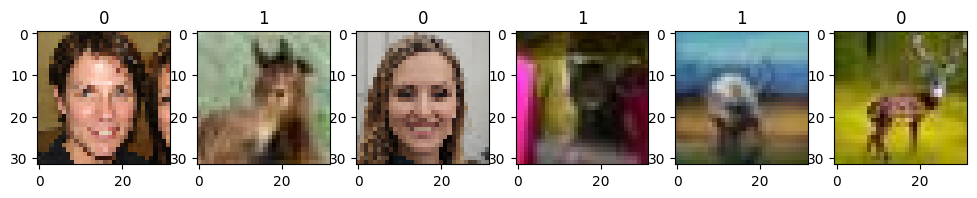

In [20]:


fig, ax = plt.subplots(ncols=6, figsize=(12, 12))
for idx, img in enumerate(batch[0][:6]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])



In [21]:
print(batch[0].min())
print(batch[0].max())


0.0
255.0


In [22]:


data = data.map(lambda x, y : (x/255, y))



In [23]:
scaled_it = data.as_numpy_iterator()


In [24]:


batch = scaled_it.next()



In [25]:
print(batch[0].min())
print(batch[0].max())


0.0
1.0


In [26]:
len(data)

7872

In [27]:
train_size = int(len(data)*0.7)
cv_size = int(len(data)*0.2)
test_size = int(len(data)*0.1)+1

In [28]:


train_size+cv_size+test_size



7872

In [29]:

train = data.take(train_size)
cv = data.skip(train_size).take(cv_size)
test = data.skip(train_size+cv_size).take(test_size)



In [30]:


len(train)+len(cv)+len(test)



7872

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten

In [32]:
model = Sequential()


In [33]:


model.add(Conv2D(16, (4, 4), 1, activation='relu', input_shape=(32, 32, 3)))
model.add(MaxPooling2D())

model.add(Conv2D(32, (4, 4), 1, activation='relu'))
model.add(MaxPooling2D())

model.add(Conv2D(16, (4, 4), 1, activation='relu'))
model.add(MaxPooling2D())

model.add(Flatten())
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))



In [34]:
model.compile('adam', loss = tf.losses.BinaryCrossentropy(), metrics=['accuracy'])

In [35]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 29, 29, 16)        784       
                                                                 
 max_pooling2d (MaxPooling2  (None, 14, 14, 16)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 32)        8224      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 5, 5, 32)          0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 2, 2, 16)          8208      
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 1, 1, 16)          0

In [36]:


logdir = 'logs'



In [37]:


tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)



In [ ]:
hist = model.fit(train, epochs=20, validation_data=cv, callbacks=[tensorboard_callback])

Epoch 1/20
 250/5510 [>.............................] - ETA: 1:38:01 - loss: 0.6937 - accuracy: 0.5093

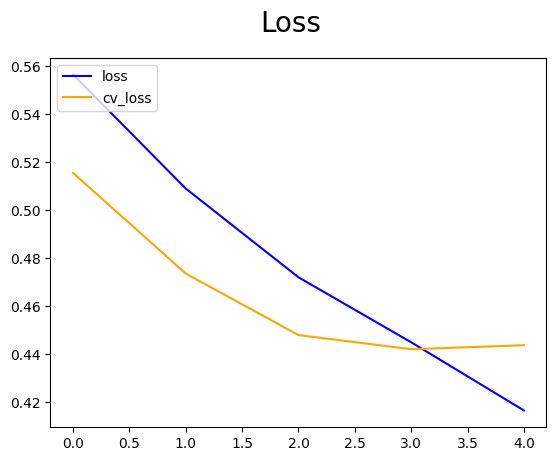

In [ ]:
fig = plt.figure()
plt.plot(hist.history['loss'], color='blue', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='cv_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

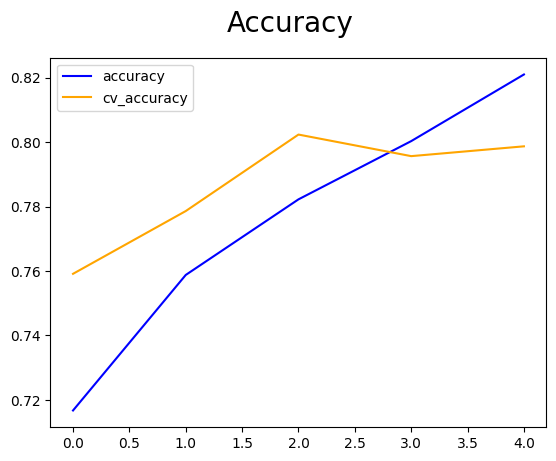

In [ ]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='blue', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='orange', label='cv_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

In [ ]:
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy


In [ ]:
pre = Precision()
rec = Recall()
acc = BinaryAccuracy()


In [ ]:


for batch in test.as_numpy_iterator():
    X, y = batch
    yhat = model.predict(X)
    pre.update_state(y, yhat)
    rec.update_state(y, yhat)
    acc.update_state(y, yhat)



1/1 [==============================] - 0s 17ms/step


In [ ]:
print(f'Precision: {pre.result().numpy()}, Recall: {rec.result().numpy()}, Accuracy: {acc.result().numpy()}')


Precision: 0.777517557144165, Recall: 0.8258706331253052, Accuracy: 0.7992700934410095


In [ ]:
from tensorflow.keras.models import load_model


In [ ]:
model.save(os.path.join('model','ai_imageclassifier2.h5'))


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
model = load_model(os.path.join('model','ai_imageclassifier2.h5'))


In [ ]:
import pickle
filename = '/content/drive/MyDrive/trained_model.sav'
pickle.dump(model,open(filename,'wb'))

In [ ]:
loaded_model = pickle.load(open('trained_model.sav','rb'))

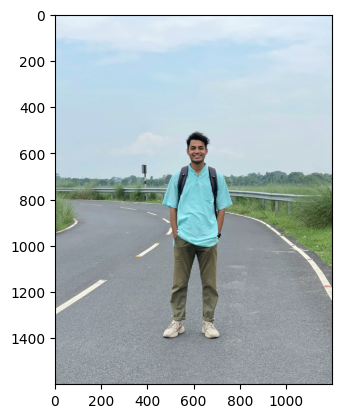

In [ ]:
img = cv2.imread('/content/drive/MyDrive/sulab.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

In [ ]:
resize = tf.image.resize(img, (32, 32))

In [ ]:
y_pred = model.predict(np.expand_dims(resize/255, 0))

1/1 [==============================] - 0s 20ms/step


In [ ]:
y_pred

array([[0.08939447]], dtype=float32)

In [ ]:
if y_pred > 0.001:
    print(f'Predicted class: REAL')
else:
    print(f'Predicted class: AI')

Predicted class: REAL
